<a href="https://colab.research.google.com/github/yunseo449/ESAA/blob/main/ESAA_YB_WEEK2_2_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###시본(Seaborn)
####시각화를 위한 차트/그래프 유형
- 특정 이산 값 칼럼에 따른 연속 값 결과 : 바/라인/파이/도넛 차트
####정보의 종류에 따른 시각화 차트 유형
- 히스토그램 : 연속형 값에 대한 도수 분포
- 바 플롯 : 특정 칼럼의 이산 값에 따른 다른 칼럼의 연속형 값을 막대 그래프 형태로 시각화
- 박스 플롯 : 연속형 값의 사분위 IQR와 최대, 최소, 이상치 값을 시각화
- 바이올린 플롯 : 히스토그램의 연속 확률 분포 곡선과 박스 플롯을 바이올린 형태로 함께 시각화
- 스캐터 플롯 : 산점도
- 상관 히트맵 : 다수의 연속형 칼럼들에 대해서 상호 간의 관계를 시각화

####히스토그램


In [1]:
#Google Drive 연동 후 불러오기
from google.colab import drive
#구글 드라이브 마운트(연결)
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd

titanic_df = pd.read_csv('/content/drive/MyDrive/ESAA/titanic_train.csv')
titanic_df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


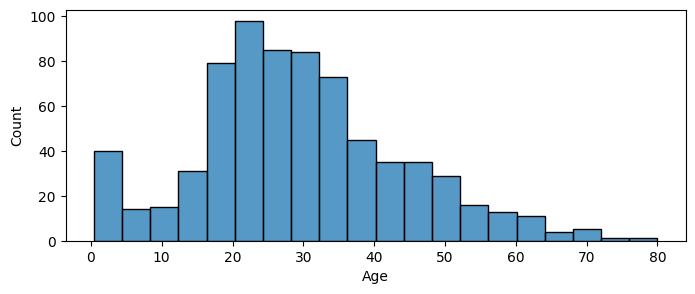

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

#시본에서도 plt.figure()의 figsize 인자를 입력하여 전체 Figure의 크기 조절
plt.figure(figsize=(8, 3))

#DataFrame의 칼럼명을 자동으로 인식해서 xlabel 값을 할당. ylabel 값은 Count로 설정.
sns.histplot(titanic_df['Age'],bins=20)
plt.show()

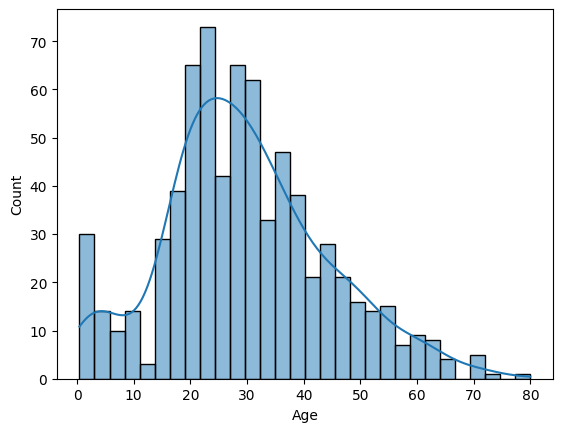

In [6]:
#연속확률분포 곡선까지 함께 시각화
sns.histplot(x='Age', data=titanic_df, bins=30, kde=True)
plt.show()

<Figure size 800x400 with 0 Axes>

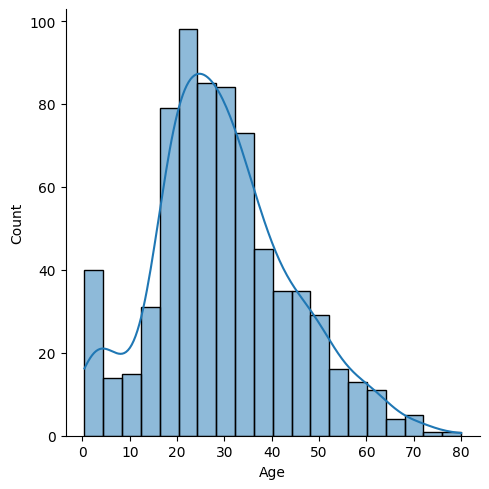

In [8]:
import seaborn as sns

#seaborn의 figure레벨 그래프는 plt.figure()로 Figure 크기를 조절할 수 없습니다.
plt.figure(figsize=(8,4))
sns.displot(x='Age', data=titanic_df, kde=True)
plt.show()

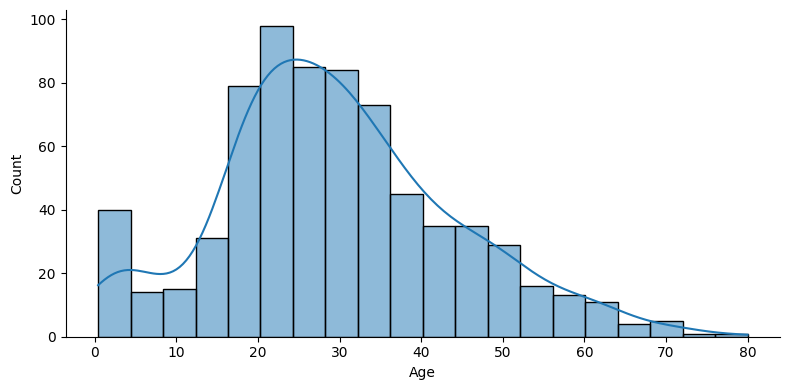

In [9]:
import seaborn as sns

sns.displot(titanic_df['Age'], kde=True, height=4, aspect=2)
plt.show()

####카운트 플롯
- 이산형 값의 건수를 막대 그래프 형태로 시각화
- 주로 카테고리성 칼럼 값별 건수를 시각화

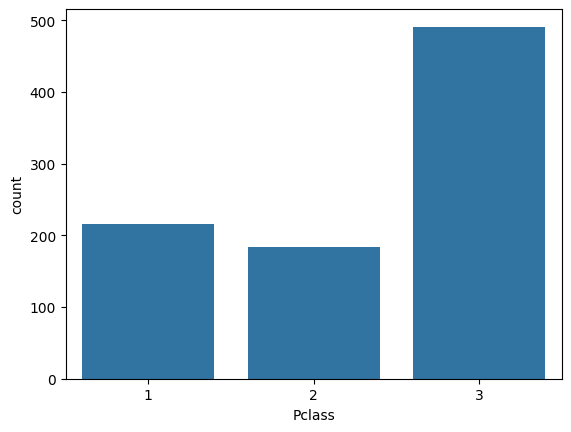

In [10]:
sns.countplot(x='Pclass', data=titanic_df)
plt.show()

####바 플롯(barplot)
- 막대 그래프 형태의 플롯
- 2차원 축 기반의 시각화에 널리 활용

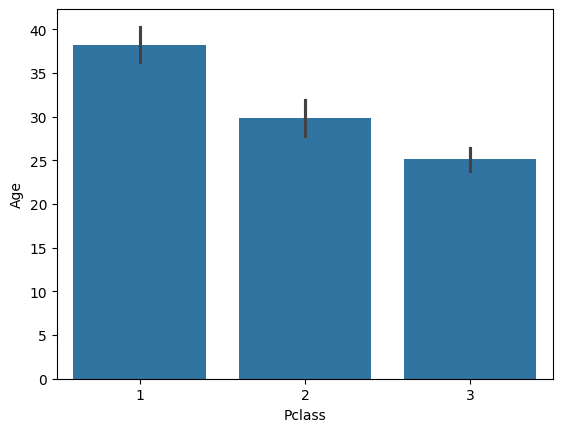

In [11]:
#자동으로 xlabel, ylabel을 barplot()의 x 인자값의 Pclass, y 인자값이 Age로 설정.
sns.barplot(x='Pclass', y='Age', data=titanic_df)
plt.show()

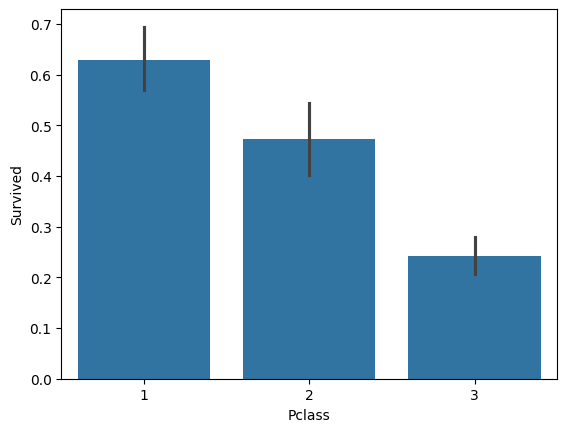

In [12]:
sns.barplot(x='Pclass', y='Survived', data=titanic_df)
plt.show()

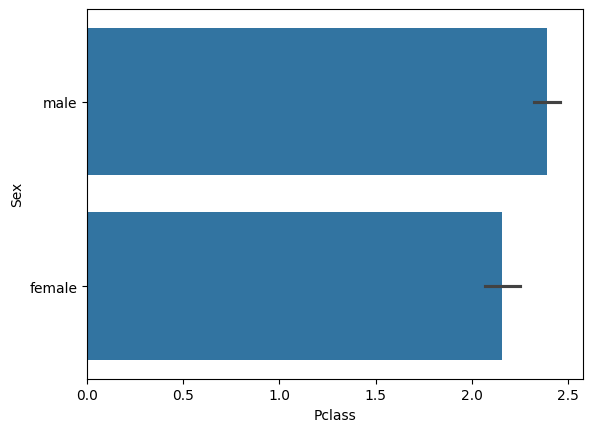

In [14]:
###y축을 문자값으로 설정하면 자동으로 수평 막대 그래프 변환
sns.barplot(x='Pclass', y='Sex', data=titanic_df)
plt.show()

<Axes: xlabel='Name', ylabel='Sex'>

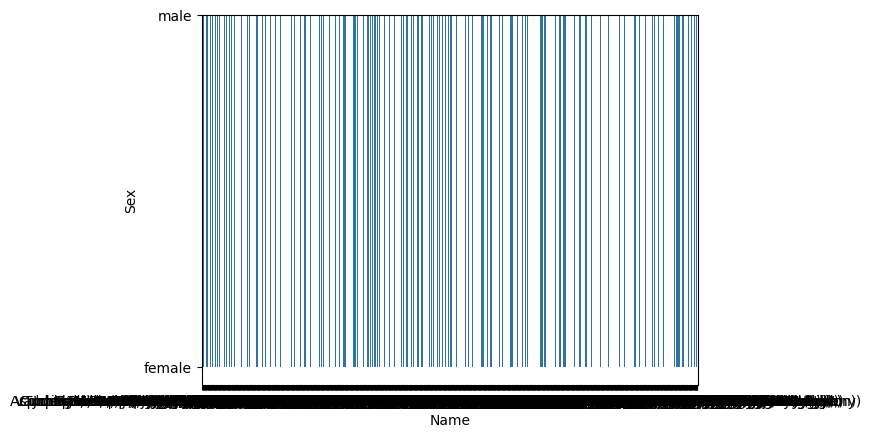

In [15]:
#x인자로 문자열인 Name을, y인자로 문자열인 Sex를 입력하므로 barplot은 오류를 발생.
sns.barplot(x='Name', y='Sex', data=titanic_df)

/tmp/ipykernel_1247/223621845.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=titanic_df, ci=None, estimator=sum)


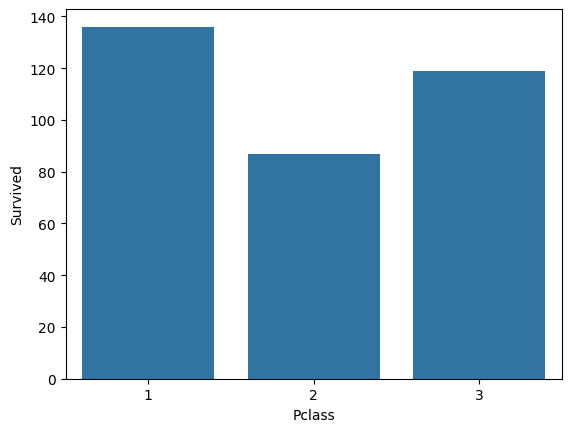

In [16]:
#estimator=sum을 적용하여 평균이 아니라 총합으로 표현.
sns.barplot(x='Pclass', y='Survived', data=titanic_df, ci=None, estimator=sum)
plt.show()

####barplot() 함수의 hue 인자를 사용하여 시각화 정보를 추가적으로 세분화하기

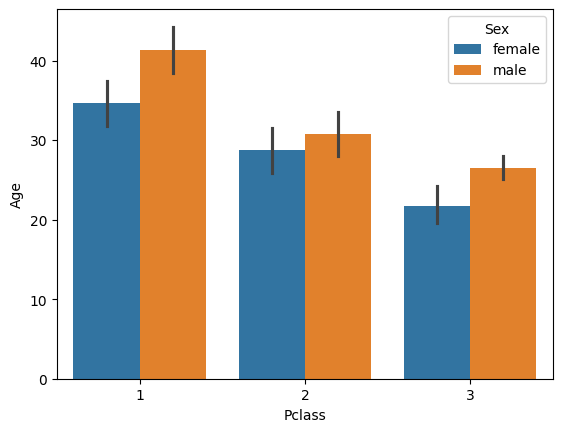

In [17]:
#아래는 Pclass가 X축값이며 hue파라미터로 Sex를 설정
#개별 Pclass 값별로 Sex에 따른 Age 평균 값을 구함.
sns.barplot(x='Pclass', y='Age', hue='Sex', data=titanic_df)
plt.show()

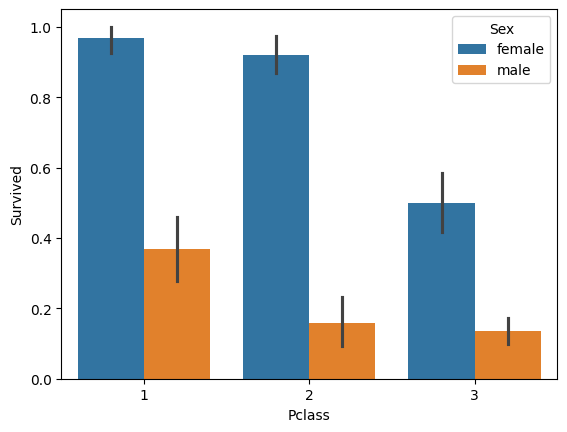

In [20]:
#개별 Pclass 값별로 Sex에 따른 Survived 평균값을 구함.
#Pclass가 X축 값이며 Survived가 Y축 값. hue 파라미터로 Sex를 설정
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=titanic_df)
plt.show()

####박스 플롯
- 연속형 값에 대한 IQR분위와 최소/최대 그리고 이상치 정보를 시각화

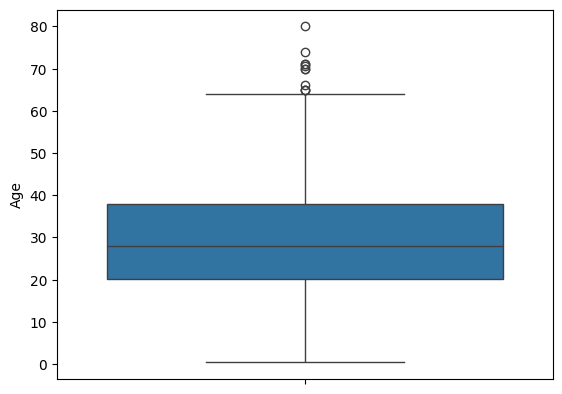

In [21]:
sns.boxplot(y='Age', data=titanic_df)
plt.show()

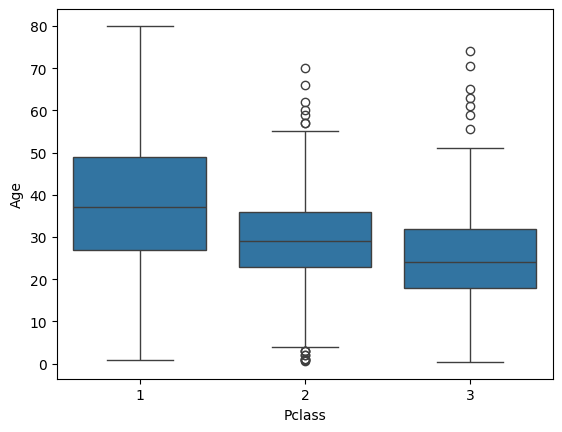

In [22]:
sns.boxplot(x='Pclass', y='Age', data=titanic_df)
plt.show()

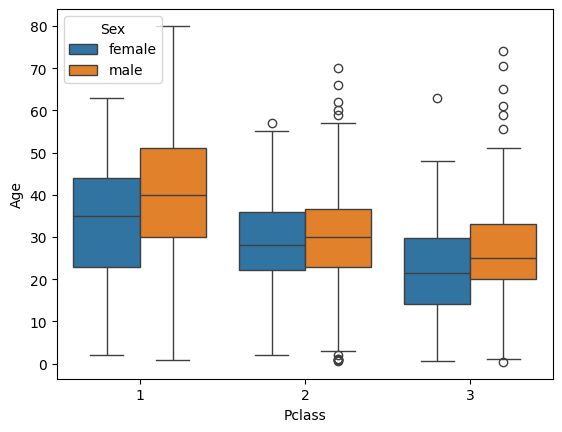

In [23]:
sns.boxplot(x='Pclass', y='Age', hue='Sex', data=titanic_df)
plt.show()

####바이올린 플롯
- 히스토그램의 연속 확률 분포 곡선과 박스 플롯을 함께 시각화

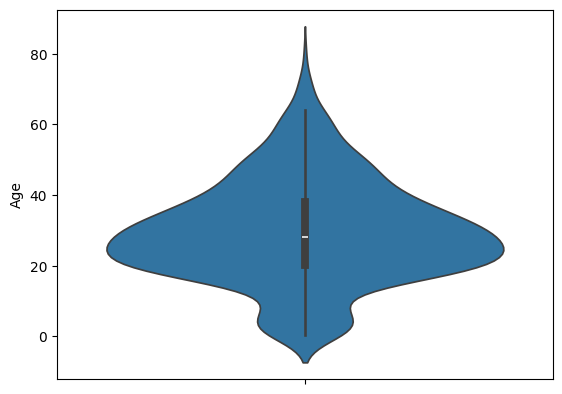

In [24]:
#Age 칼럼에 대한 수직 바이올린 플롯 시각화
sns.violinplot(y='Age', data=titanic_df)
plt.show()

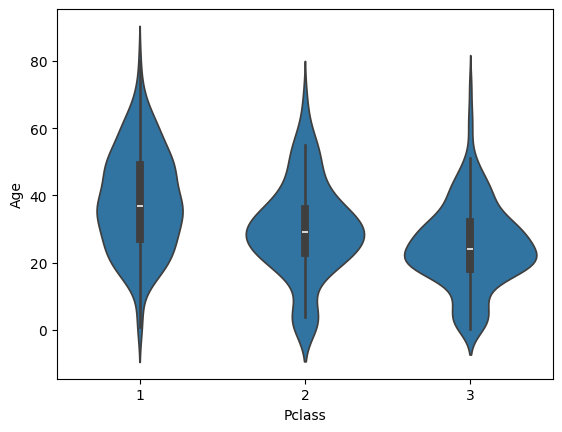

In [25]:
#x축값인 Pclass의 값별로 y축 값인 Age의 바이올린 플롯을 그림
#pclass값별로 Age 데이터 분포를 비교하여 볼 수 있음.
sns.violinplot(x='Pclass', y='Age', data=titanic_df)
plt.show()

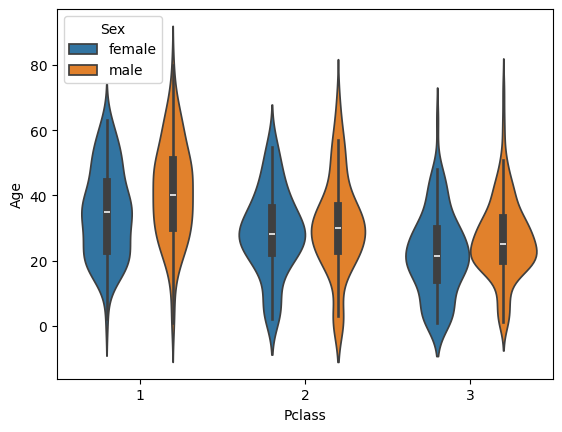

In [26]:
#x축값인 개별 Pclass 내에서 Sex값별로 y축 값인 Age의 바이올린 플롯을 그림
sns.violinplot(x='Pclass', y='Age', hue='Sex', data=titanic_df)
plt.show()

####subplots를 이용하여 시본의 다양한 그래프를 시각화

index: 0
index: 1
index: 2


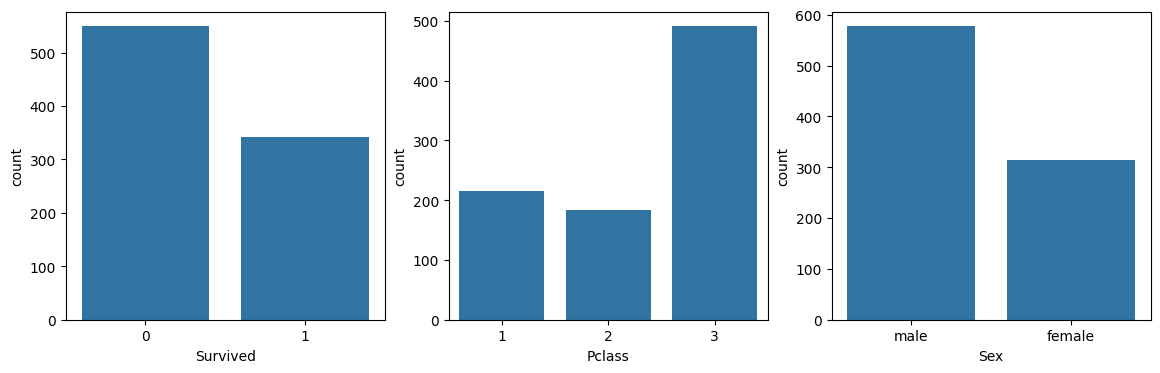

In [27]:
cat_columns = ['Survived', 'Pclass', 'Sex']

#nrows는 1이고 ncols는 칼럼의 개수만큼인 subplots를 설정.
fig, axes = plt.subplots(nrows=1, ncols=len(cat_columns), figsize=(14, 4))

for index, column in enumerate(cat_columns):
  print('index:', index)
  #seaborn의 Axes 레벨 function들은 ax 인자로 subplots의 어느 Axes에 위치할지 설정.
  sns.countplot(x=column, data=titanic_df, ax=axes[index])

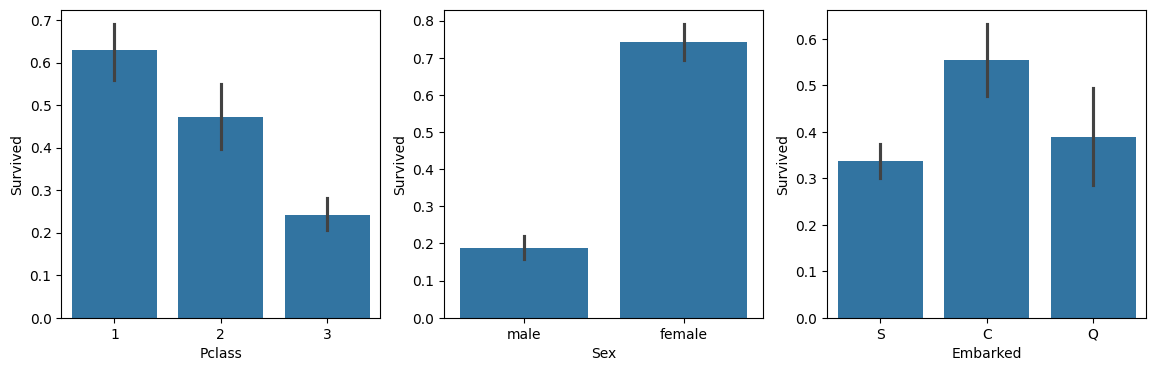

In [29]:
cat_columns = ['Pclass', 'Sex', 'Embarked']

#nrows는 1이고 ncols는 칼럼의 개수만큼인 subplots을 설정.
fig, axs = plt.subplots(nrows=1, ncols=len(cat_columns), figsize=(14, 4))

for index, column in enumerate(cat_columns):
  #seaborn의 Axes 레벨 function들은 ax 인자로 subplots의 어느 Axes에 위치할지 설정.
  sns.barplot(x=column, y='Survived', data=titanic_df, ax=axs[index])

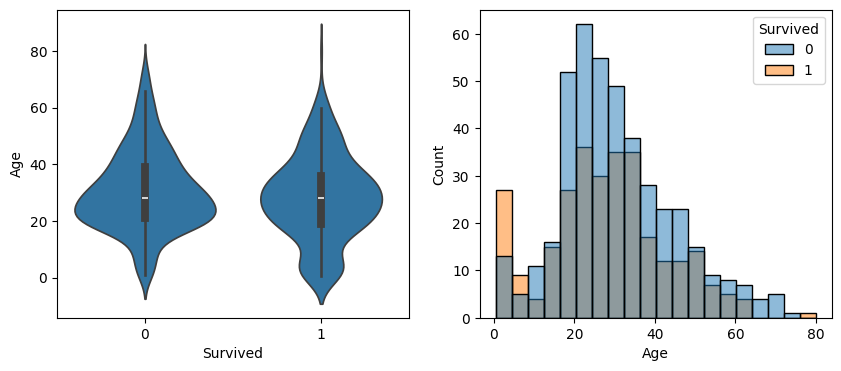

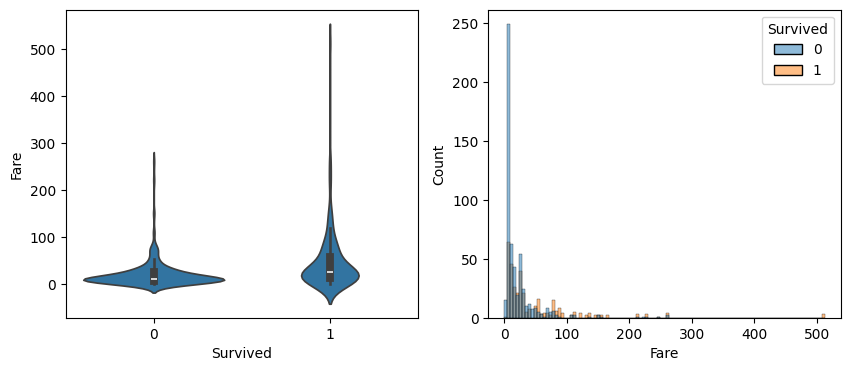

In [30]:
cont_columns = ['Age', 'Fare']

#리스트로 할당된 칼럼들의 개수만큼 루프 수행.
for column in cont_columns:
  #왼쪽에는 바이올린 플롯, 오른쪽에는 히스토그램을 시각화. nrows는 1, ncols=2의 서브플롯 생성.
  fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
  #왼쪽 Axes 객체에는 Survived값 0, 1별 개별 칼럼의 바이올린 플롯 시각화.
  sns.violinplot(x='Survived', y=column, data=titanic_df, ax=axes[0])
  #오른쪽 Axes 객체에는 Survived값 0, 1별 개별 칼럼의 히스토그램 시각화
  sns.histplot(x=column, hue='Survived', data=titanic_df, ax=axes[1])

####산점도, 스캐터 플롯(Scatter Plot)
- 좌표상에 점을 표시하여 변수 간의 관계를 나타
- X축 값, Y축 값 모두 연속형 숫자값을 적용해야 의미 있는 시각화 정보를 얻을 수 있음.

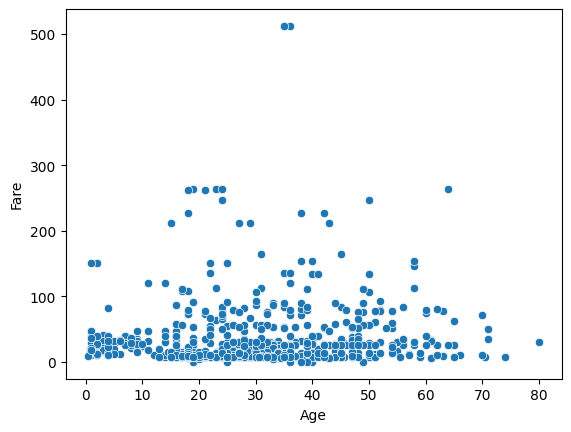

In [32]:
#X축값으로 Age를, Y축값으로 Fare을 설정
sns.scatterplot(x='Age', y='Fare', data=titanic_df)
plt.show()

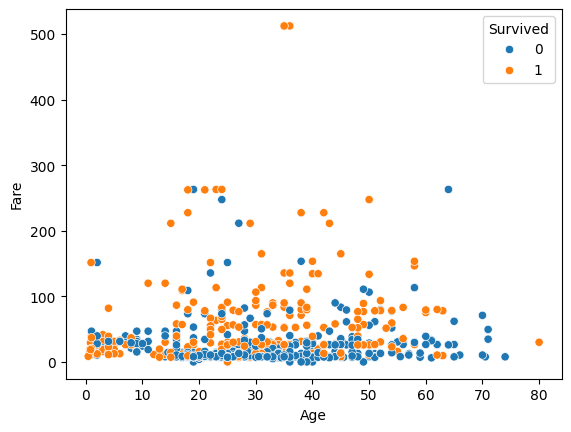

In [34]:
#사망/생존으로 추가적인 분리 적용
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=titanic_df)
plt.show()

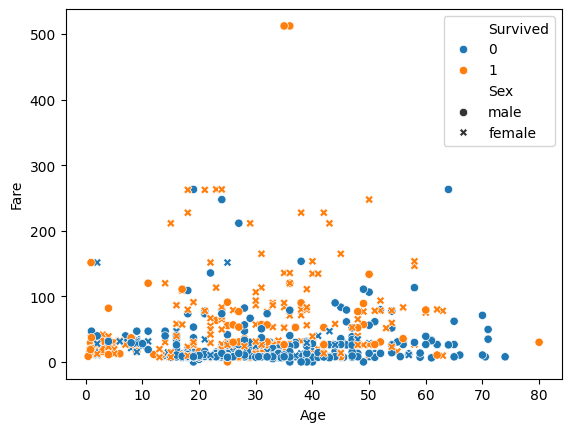

In [36]:
#더 세분화된 추가 정보
sns.scatterplot(x='Age', y='Fare', hue='Survived', style='Sex', data=titanic_df)
plt.show()

####상관 히트맵(Correlation Heatmap)
- 다수의 속성들 간의 상관계수를 히트맵 형태로 나타냄
- 두 속성의 값이 서로 상관없으면 0이며, 같은 방향으로 완전히 동일하면 1, 반대 방향으로 완전히 동일하면 -1을 값으로 가짐.

In [39]:
corr_df = titanic_df.corr(numeric_only=True)
corr_df

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


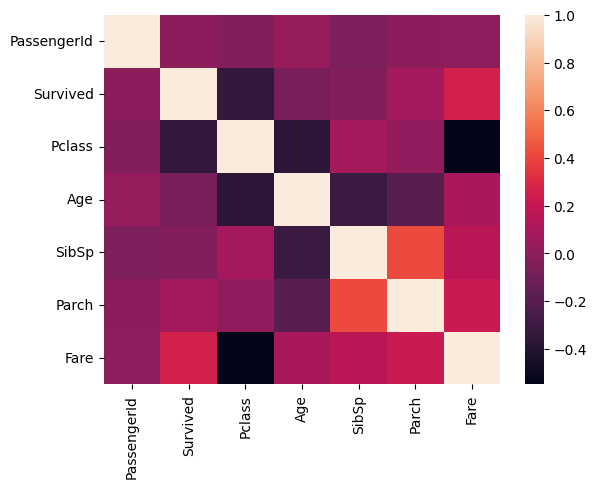

In [41]:
# 상관계수를 DataFrame으로 구하고 이를 heatmap()의 인자로 입력
corr = titanic_df.corr(numeric_only=True)
sns.heatmap(corr)
plt.show()

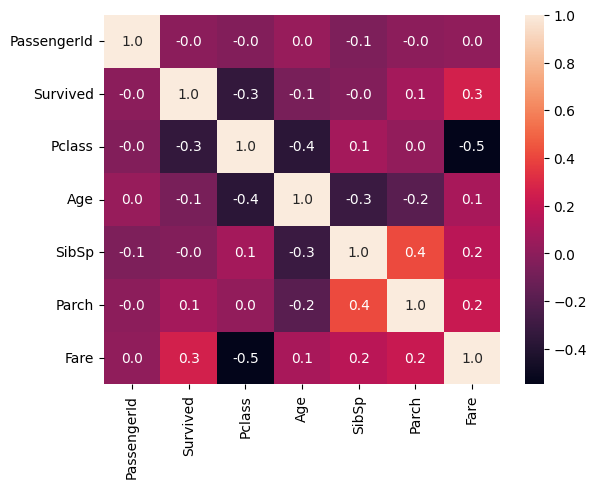

In [42]:
#annot=True일 경우 숫자로 된 상관계숫값을 표시해 줌
#fmt인자로 숫자값의 포맷 변환
sns.heatmap(corr, annot=True, fmt='.1f', cbar=True)
plt.show()